Intro.

Fuentes utilizadas.

Librerías utilizadas.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from scipy.stats import shapiro, pearsonr, spearmanr

Cargamos los datos.

In [2]:
df1 = pd.read_csv("data/emancipacion.csv", sep="\t", encoding="cp1252")
df2 = pd.read_csv("data/salario.csv", sep="\t", encoding="cp1252")
df1_nogenero = pd.read_csv("data/emancipacionsingenero.csv", sep="\t", encoding="cp1252")
df2_nogenero = pd.read_csv("data/salariosingenero.csv", sep="\t", encoding="cp1252")

Limpiamos los dataframe.

In [3]:
# Borramos grupo de edad que es siempre el mismo
df1.drop(columns=["Grupo de edad"], inplace=True)

# Pasamos a miles de personas para poder ver el df mejor
df1["Total"] = (
    pd.to_numeric(df1["Total"].astype(str).str.replace(",", ".", regex=False), errors="coerce") * 1000
).round().astype("Int64")

# Juntamos a los no emancipados y los diferenciamos de los si emancipados
no_emancipados = [
    "Hijos/Hijas no del padre o madre solos",
    "Hijos/Hijas del padre o madre solos"
]

df1["Emancipado"] = df1["Situación en el hogar"].isin(no_emancipados)
df1["Emancipado"] = df1["Emancipado"].replace({
    True: "No emancipado",
    False: "Si emancipado"
})

df1 = df1.groupby(
    ["Comunidades y Ciudades Autónomas", "Sexo", "periodo", "Emancipado"],
    as_index=False
)["Total"].sum()

df1 = df1.pivot(
    index=["Comunidades y Ciudades Autónomas", "Sexo", "periodo"],
    columns="Emancipado",
    values="Total"
).reset_index()

df1.columns.name = None

# Hacemos las proporciones de los si emancipados y no emancipados
df1["total_personas"] = df1["Si emancipado"] + df1["No emancipado"]

df1["Si emancipado%"] = df1["Si emancipado"] / df1["total_personas"]
df1["No emancipado%"] = df1["No emancipado"] / df1["total_personas"]


df1["Si emancipado%"] = df1["Si emancipado%"] * 100
df1["No emancipado%"] = df1["No emancipado%"] * 100

df1["Si emancipado%"] = df1["Si emancipado%"].round(3)
df1["No emancipado%"] = df1["No emancipado%"].round(3)

df1.drop(columns=["total_personas"], inplace=True)

In [4]:
# Borramos grupo de edad
df2.drop(columns=["Edad del trabajador"], inplace=True)

# Pasamos los valores a numeros
df2["Total"] = pd.to_numeric(
    df2["Total"].astype(str).str.replace(".", "", regex=False).str.replace(",", ".", regex=False),
    errors="coerce"
).abs()

# Ponemos sexo en singular
df2["Sexo"] = df2["Sexo"].replace({
    "Hombres": "Hombre",
    "Mujeres": "Mujer"
})

In [5]:
# Borramos grupo de edad y sexo que es siempre el mismo
df1_nogenero.drop(columns=["Grupo de edad", "Sexo"], inplace=True)

# Pasamos a miles de personas para poder ver el df mejor
df1_nogenero["Total"] = (
    pd.to_numeric(df1_nogenero["Total"].astype(str).str.replace(",", ".", regex=False), errors="coerce") * 1000
).round().astype("Int64")

# Juntamos a los no emancipados y los diferenciamos de los si emancipados
no_emancipados = [
    "Hijos/Hijas no del padre o madre solos",
    "Hijos/Hijas del padre o madre solos"
]

df1_nogenero["Emancipado"] = df1_nogenero["Situación en el hogar"].isin(no_emancipados)
df1_nogenero["Emancipado"] = df1_nogenero["Emancipado"].replace({
    True: "No emancipado",
    False: "Si emancipado"
})

df1_nogenero = df1_nogenero.groupby(
    ["Comunidades y Ciudades Autónomas", "periodo", "Emancipado"],
    as_index=False
)["Total"].sum()

df1_nogenero = df1_nogenero.pivot(
    index=["Comunidades y Ciudades Autónomas", "periodo"],
    columns="Emancipado",
    values="Total"
).reset_index()

df1_nogenero.columns.name = None

# Hacemos las proporciones de los si emancipados y no emancipados
df1_nogenero["total_personas"] = df1_nogenero["Si emancipado"] + df1_nogenero["No emancipado"]
df1_nogenero["Si emancipado%"] = df1_nogenero["Si emancipado"] / df1_nogenero["total_personas"]
df1_nogenero["No emancipado%"] = df1_nogenero["No emancipado"] / df1_nogenero["total_personas"]


df1_nogenero["Si emancipado%"] = df1_nogenero["Si emancipado%"] * 100
df1_nogenero["No emancipado%"] = df1_nogenero["No emancipado%"] * 100

df1_nogenero["Si emancipado%"] = df1_nogenero["Si emancipado%"].round(3)
df1_nogenero["No emancipado%"] = df1_nogenero["No emancipado%"].round(3)

df1_nogenero.drop(columns=["total_personas"], inplace=True)

In [6]:
# Borramos grupo de edad
df2_nogenero.drop(columns=["Edad del trabajador"], inplace=True)

# Pasamos los valores a numeros
df2_nogenero["Total"] = pd.to_numeric(
    df2_nogenero["Total"].astype(str).str.replace(".", "", regex=False).str.replace(",", ".", regex=False),
    errors="coerce"
).abs()

En resumen, hemos hecho limpiezas muy similares para la emancipación y la emancipación sin género, al igual que en el caso del salario y el salario sin género.

Para la emancipación y la emancipación sin género, eliminamos columnas que no aportan información. Seguidamente los datos de la columna Total, lo pasamos a miles de personas para poder verlo mejor y trabajar con él. Después juntamos a todos los emancipados y a los no emancipados, que es el dato que nos interesa, y sumamos sus totales. Finalmente calculamos las proporciones de los emancipados y no emancipados, para poder trabajar con los datos relativos.

En el segundo caso, es más simple la limpieza. Primero borramos columnas inservibles. Seguidamente cambiamos el punto en los valores del Total, para que a la hora de hacer el análisis el programa entienda bien los datos. Por último, para el salario con el género, ponemos las categorías en singular, para que no de error a la hora de compararlo con la emancipación.


Análisis univariante

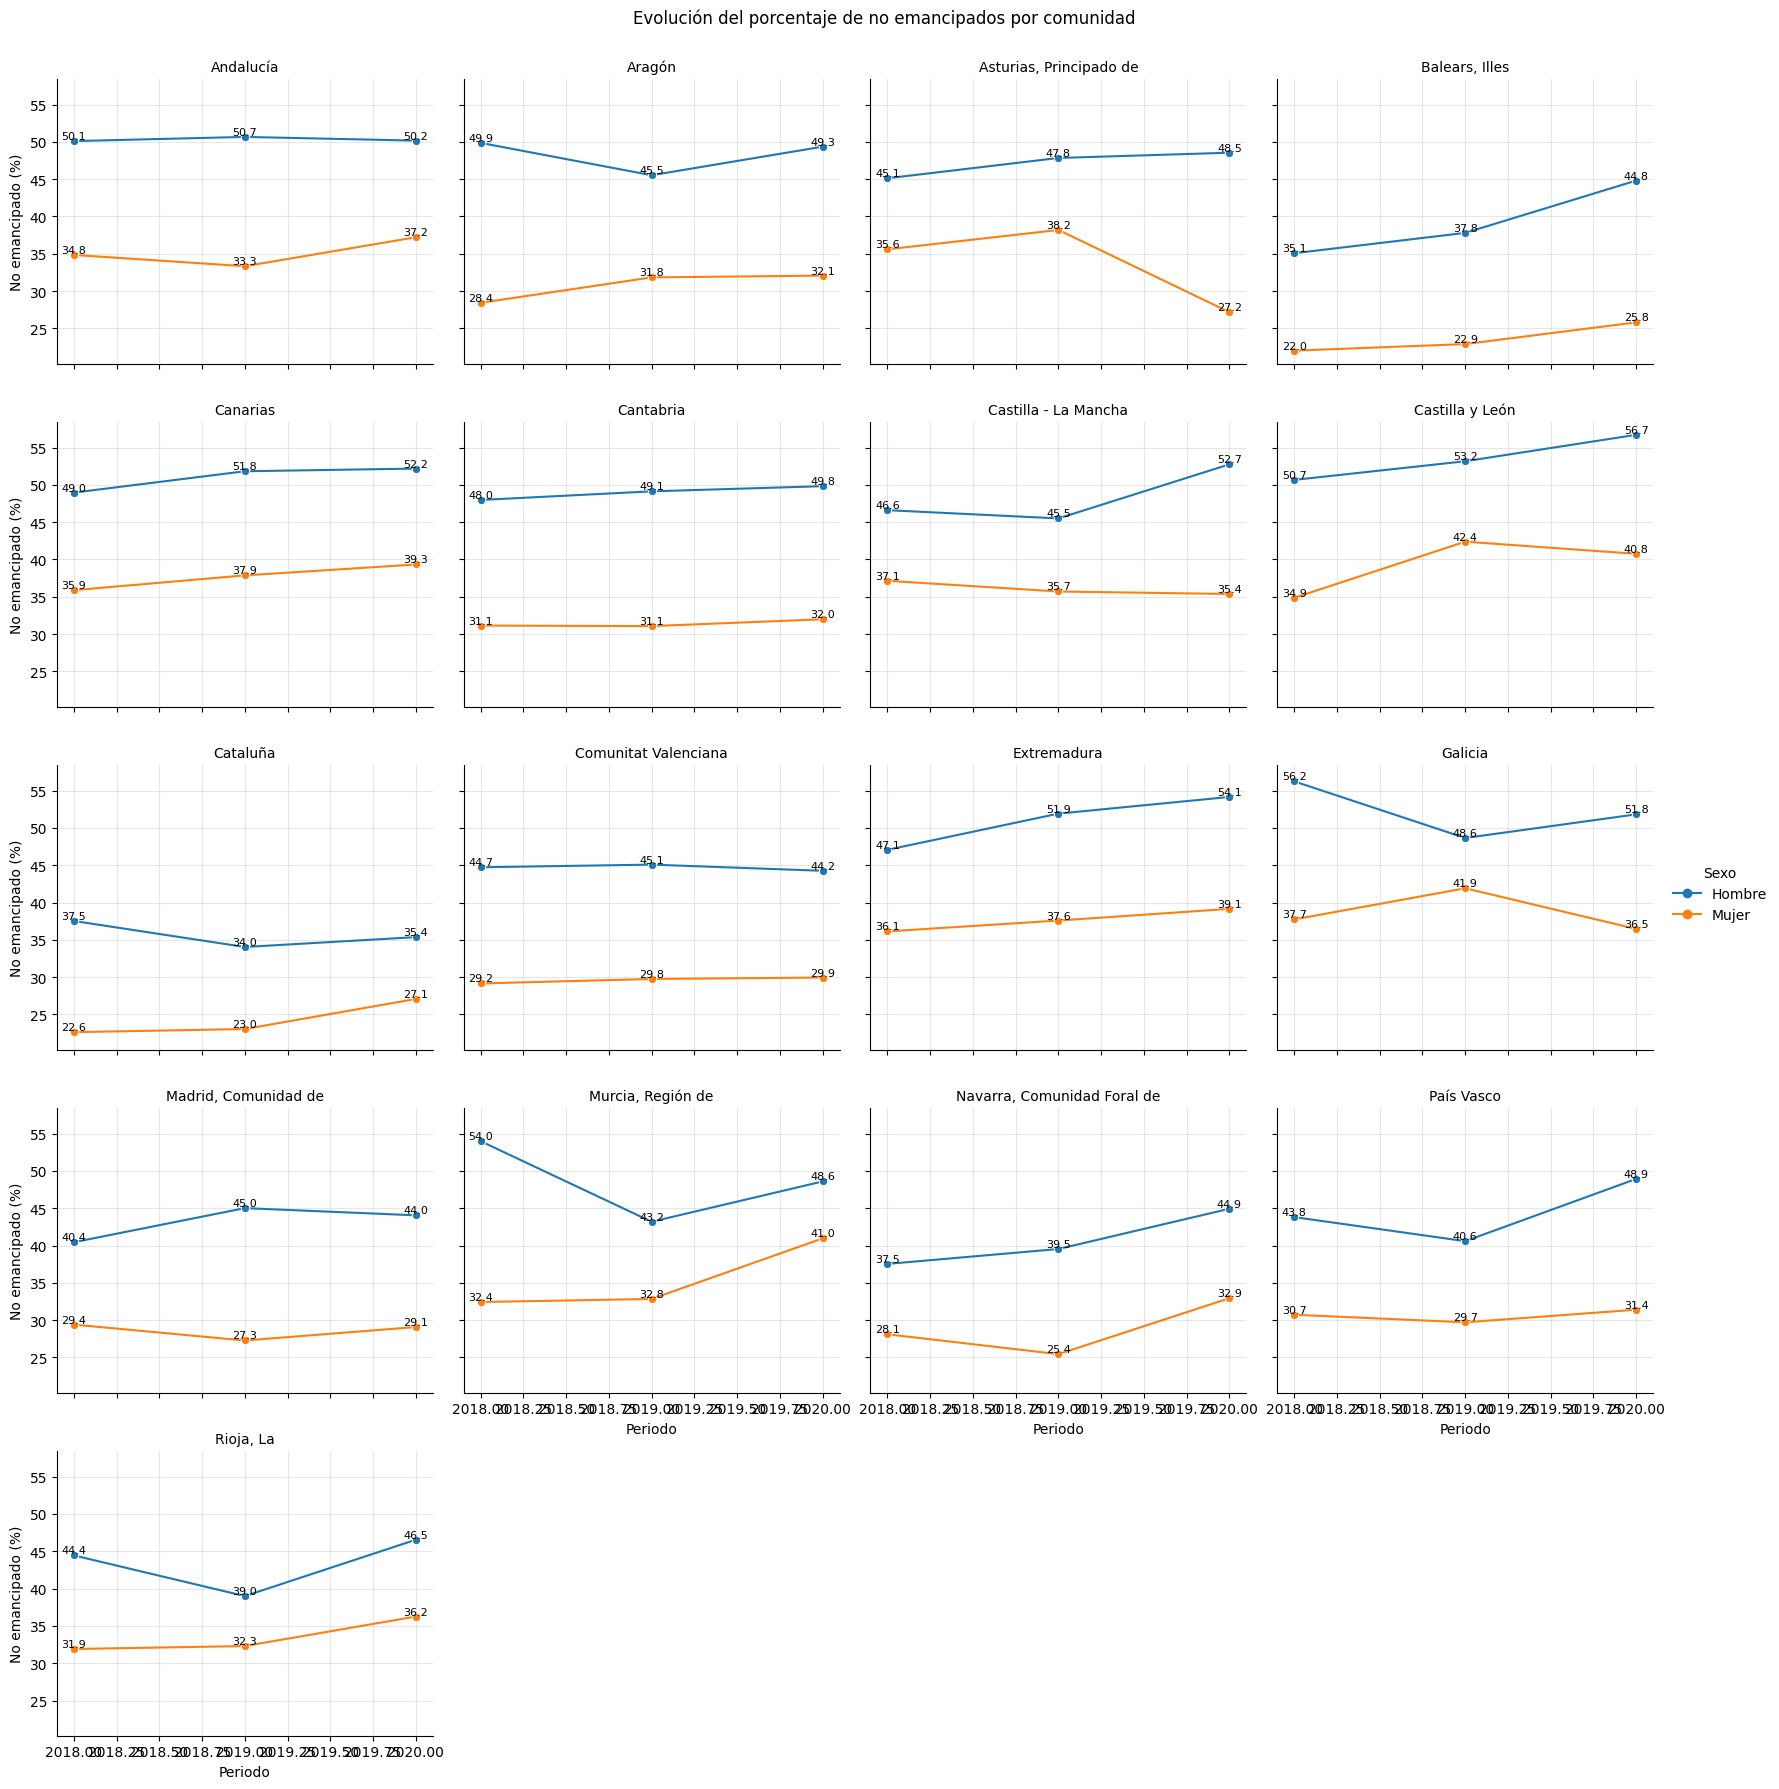

In [7]:
df_plot = df1.copy()

df_plot["periodo"] = pd.to_numeric(df_plot["periodo"], errors="coerce")
df_plot = df_plot[df_plot["Sexo"].isin(["Hombre", "Mujer"])].copy()
df_plot = df_plot.sort_values(["Comunidades y Ciudades Autónomas", "Sexo", "periodo"])

g = sns.relplot(
    data=df_plot,
    x="periodo",
    y="No emancipado%",
    hue="Sexo",
    kind="line",
    col="Comunidades y Ciudades Autónomas",
    col_wrap=4,
    marker="o",
    height=3.5,
    aspect=1.2,
    facet_kws={"sharey": True, "sharex": True}
)

g.set_axis_labels("Periodo", "No emancipado (%)")
g.set_titles("{col_name}")
g.fig.suptitle("Evolución del porcentaje de no emancipados por comunidad", y=1.02)

for ax in g.axes.flat:
    titulo = ax.get_title().replace("Comunidades y Ciudades Autónomas = ", "")
    datos_ax = df_plot[df_plot["Comunidades y Ciudades Autónomas"] == titulo]

    for sexo in ["Hombre", "Mujer"]:
        datos_sexo = datos_ax[datos_ax["Sexo"] == sexo]
        for _, row in datos_sexo.iterrows():
            ax.text(
                row["periodo"],
                row["No emancipado%"],
                f'{row["No emancipado%"]:.1f}',
                fontsize=8,
                ha="center",
                va="bottom"
            )

    ax.grid(True, alpha=0.3)

plt.show()

Obtenemos la proporción de hombres y mujeres no emancipadas por comunidad autónoma. El resultado es que en todas y cada una de las comunidades autónomas el resultado la proporción de hombres no emancipados es mayor en todas. Varían generalmente un 10% más como mínimo para los hombres, exceptuando algún caso concreto, como Murcia (2019-2020), La Rioja (2019-2020), o Galicia en 2019. Para las demás lo que llegan a alejarse como máximo en un 20% en los casos más extremos, siendo esto superado únicamente por Asturias en 2020, con un 21,3% de diferencia entre hombres y mujeres. 

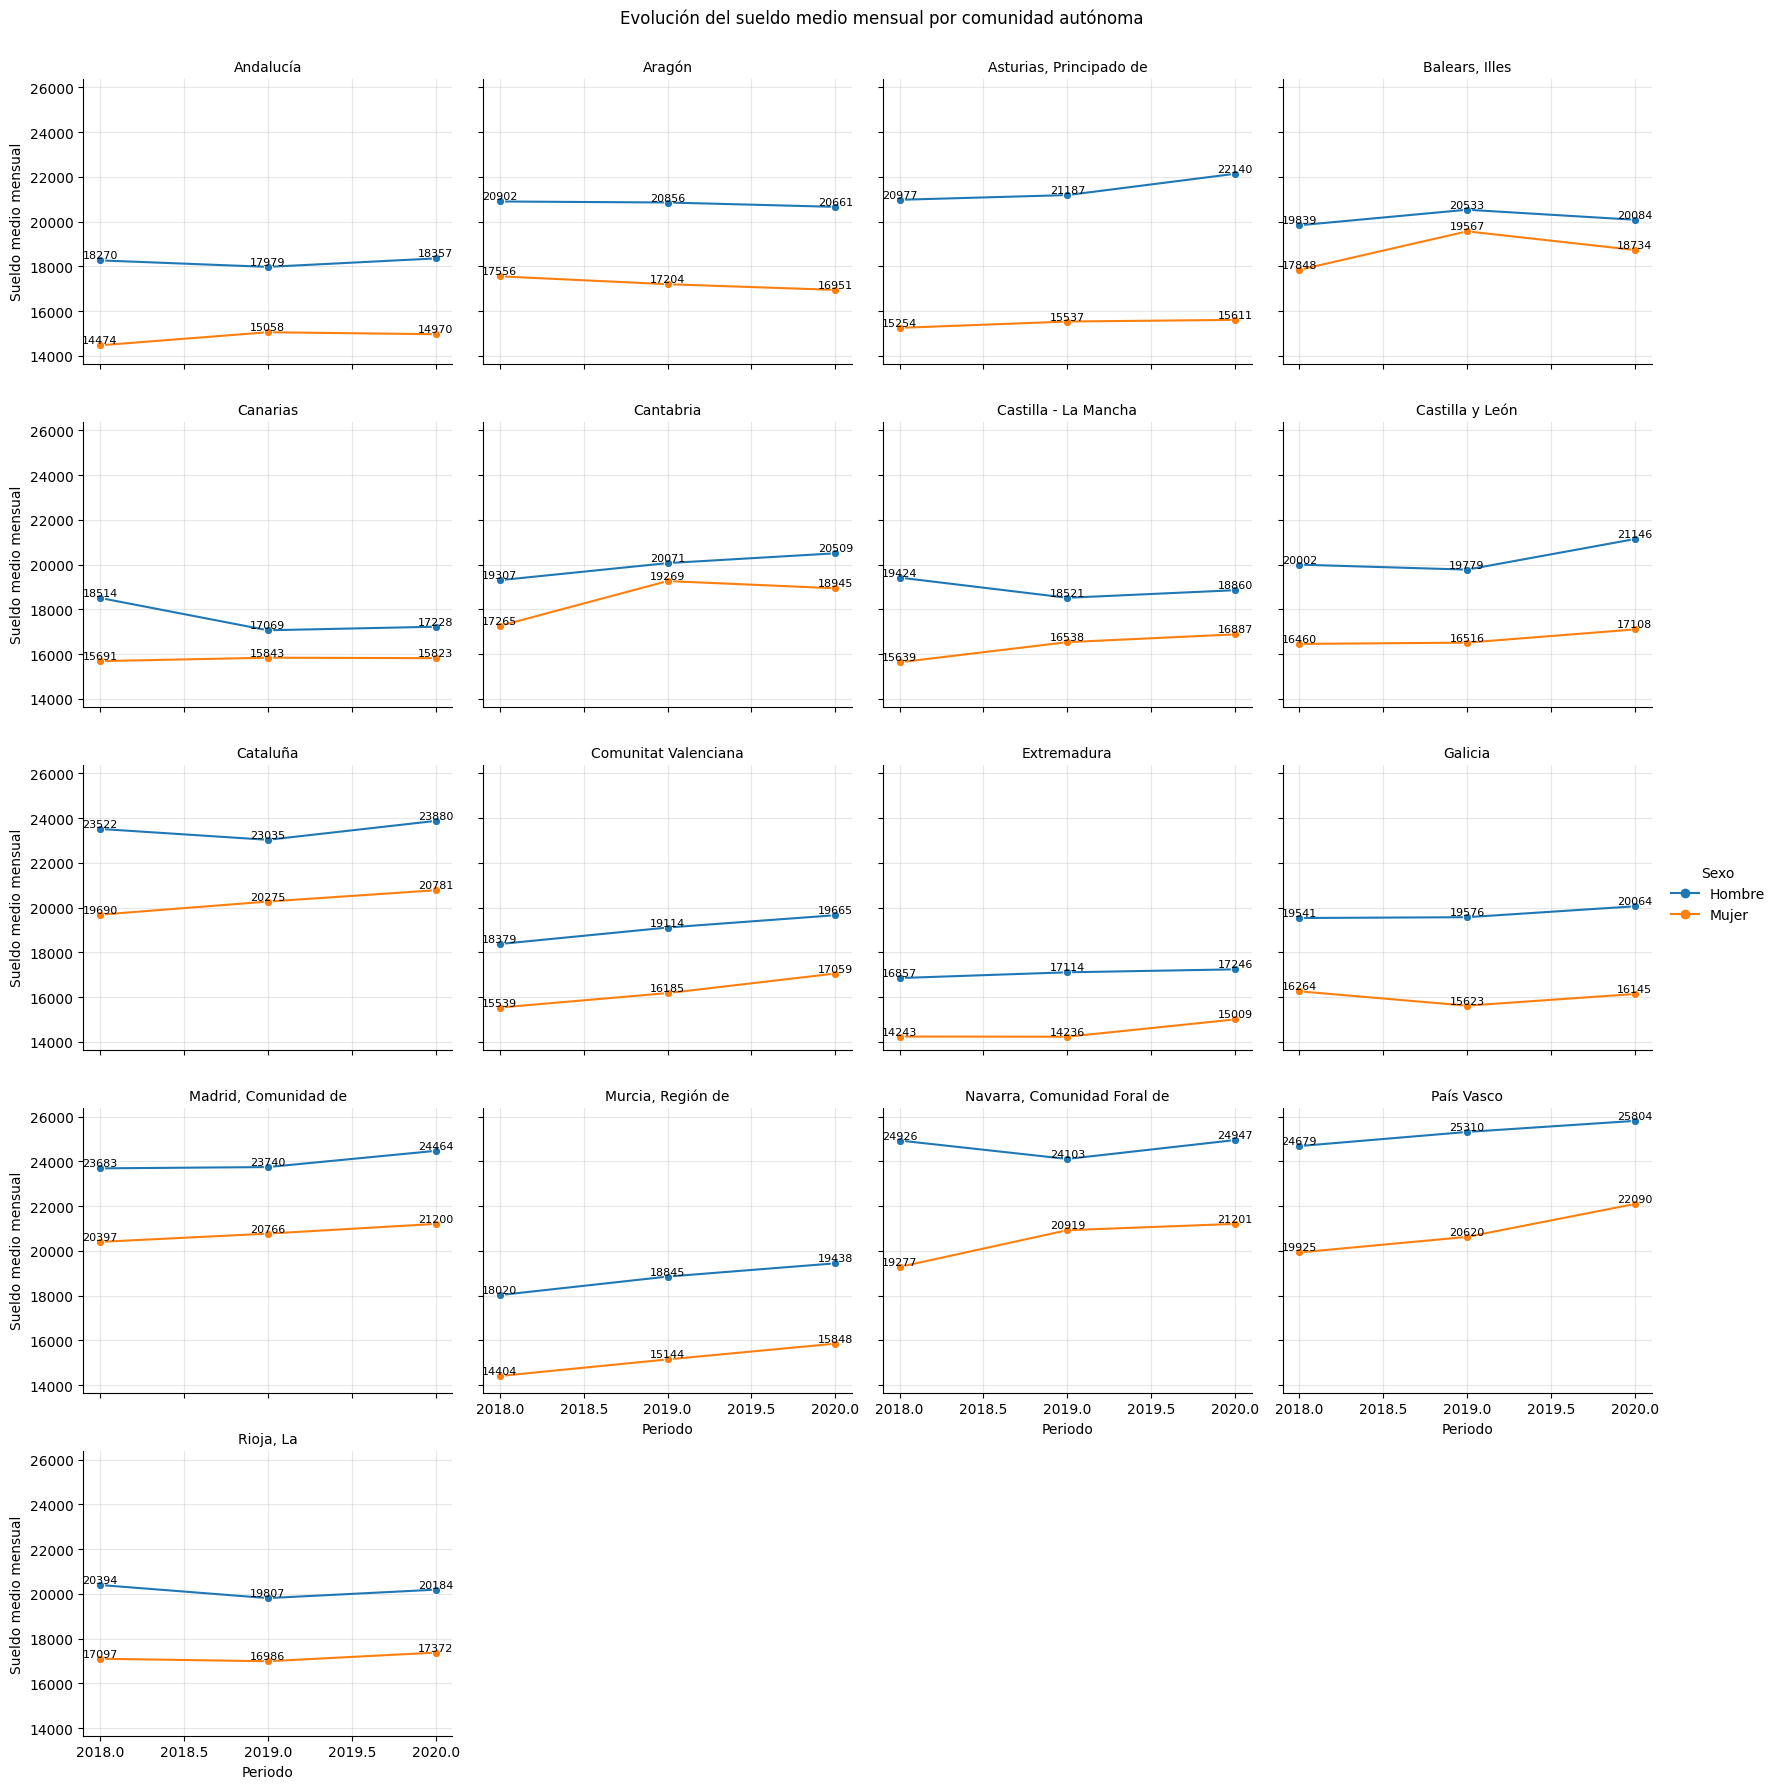

In [8]:
df_plot = df2.copy()
df_plot["Periodo"] = pd.to_numeric(df_plot["Periodo"], errors="coerce")
df_plot = df_plot[df_plot["Sexo"].isin(["Hombre", "Mujer"])].copy()
df_plot = df_plot.sort_values(["Comunidades y Ciudades Autónomas", "Sexo", "Periodo"])

g = sns.relplot(
    data=df_plot,
    x="Periodo",
    y="Total",
    hue="Sexo",
    kind="line",
    col="Comunidades y Ciudades Autónomas",
    col_wrap=4,
    marker="o",
    height=3.5,
    aspect=1.2,
    facet_kws={"sharey": True, "sharex": True}
)

g.set_axis_labels("Periodo", "Sueldo medio mensual")
g.set_titles("{col_name}")
g.fig.suptitle("Evolución del sueldo medio mensual por comunidad autónoma", y=1.02)

for ax in g.axes.flat:
    titulo = ax.get_title().replace("Comunidades y Ciudades Autónomas = ", "")
    datos_ax = df_plot[df_plot["Comunidades y Ciudades Autónomas"] == titulo]

    for _, row in datos_ax.iterrows():
        ax.text(
            row["Periodo"],
            row["Total"],
            f'{row["Total"]:.0f}',
            fontsize=8,
            ha="center",
            va="bottom"
        )

    ax.grid(True, alpha=0.3)

plt.show()

Ahora estamos viendo como evoluciona el salario medio anual, para hombres y para mujeres por CCAA, entre el 2018 y el 2020. Como en el caso de la emancipación, las mujeres presentan un sueldo medio anual menor que los hombres en todas las CCAA. En esta ocasion vemos que hay comunidades donde los sueldos están más parejos, como pueden ser: Las Islas Baleares; Las Islas; Cantabria; Castilla La Mancha. Por otro lado, en las demás vemos algo más de diferencia en el sueldo medio anual entre hombres y mujeres, siendo el caso más extremo el de Asturias.

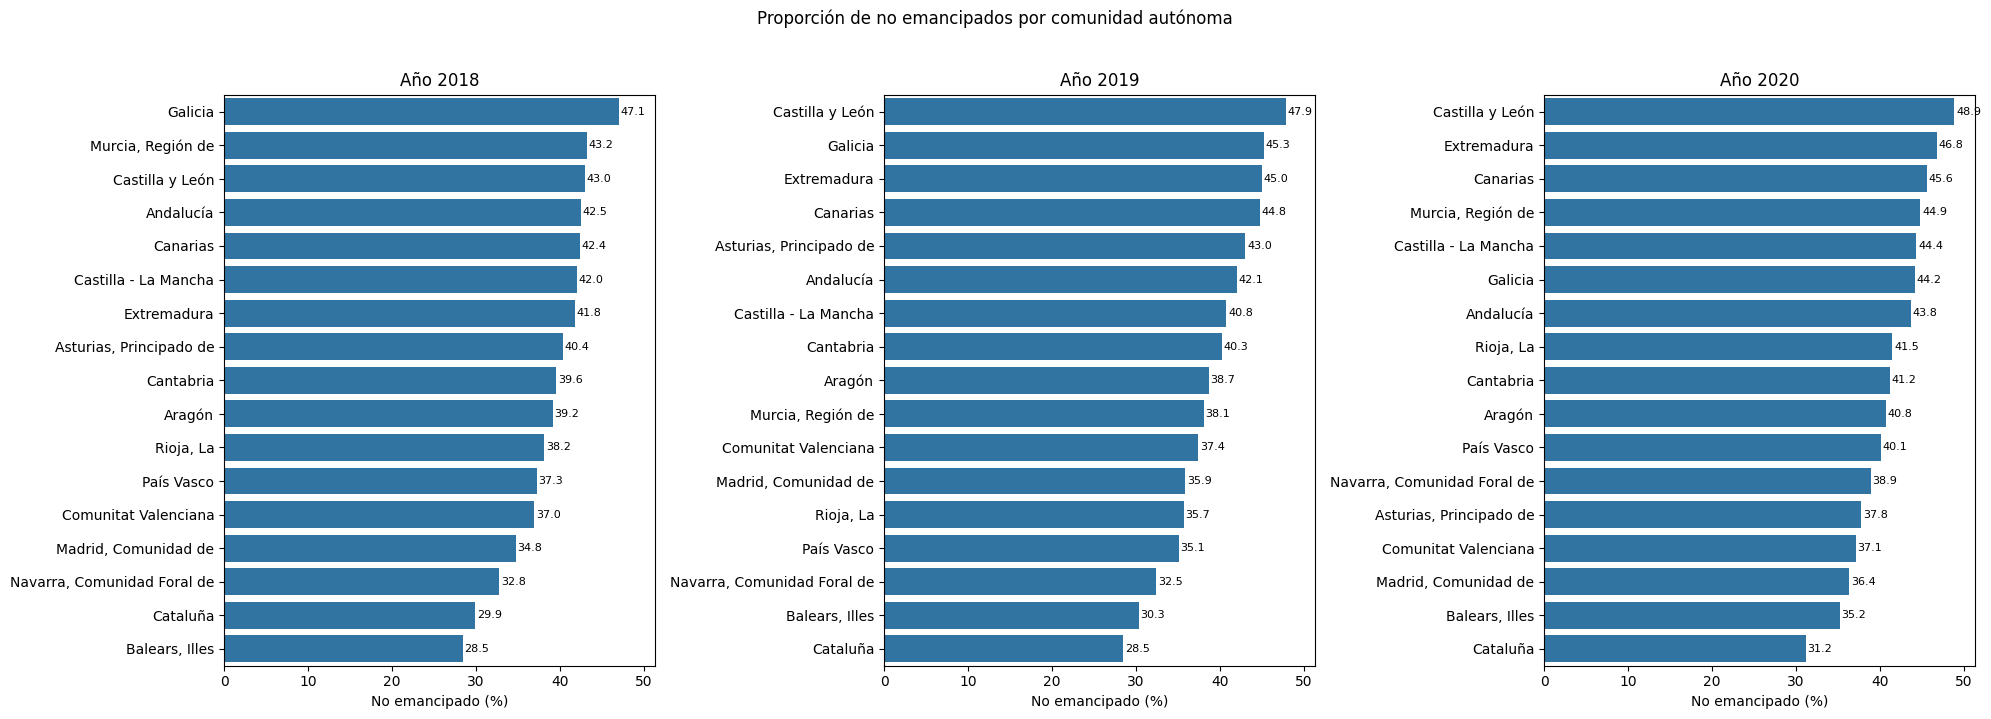

In [9]:
periodos = sorted(df1_nogenero["periodo"].unique())

fig, axes = plt.subplots(1, len(periodos), figsize=(20, 7), sharex=True)

if len(periodos) == 1:
    axes = [axes]

for ax, periodo in zip(axes, periodos):
    datos = df1_nogenero[df1_nogenero["periodo"] == periodo].copy()
    datos = datos.sort_values("No emancipado%", ascending=False)

    sns.barplot(
        data=datos,
        x="No emancipado%",
        y="Comunidades y Ciudades Autónomas",
        ax=ax,
        order=datos["Comunidades y Ciudades Autónomas"]
    )

    ax.set_title(f"Año {periodo}")
    ax.set_xlabel("No emancipado (%)")
    ax.set_ylabel("")

    for i, valor in enumerate(datos["No emancipado%"]):
        ax.text(valor + 0.2, i, f"{valor:.1f}", va="center", fontsize=8)

plt.suptitle("Proporción de no emancipados por comunidad autónoma", y=1.02)
plt.tight_layout()
plt.show()

Lo que vemos son los ranking de CCAA con la proporción de no emancipados, ordenados de mayor a menor, entre 2018 y 2020. A simple vista vemos como el máximo no disminuye de los 47%, ni supera los 49% en ningún año. Por otro lado, el mínimo no baja de 28.5% ni supera los 31.2%. 

Vemos que hay comunidades que encabezando el ranking consiguen mejorar en este periodo y acabar bajando posiciones, como por ejemplo: Galicia; Murcia; Andalucía. Si nos fijamos en la cola del ranking, tenemos comunidades que se repiten todos los años: Las Islas Baleares; Cataluña; Madrid; Navarra; Comunidad Valenciana. 

Asturias ha acabado en 2020 con una gran mejoría, Murcia consiguió bajar su proporción bastante entre 2018 y 2019, pero la aumentó para 2020. En general acabaron empeorando: Castilla y León; Extremadura; Canarias; La Rioja. Aragón; Cantabria; País Vasco, se mantuvieron estables en mitad de la tabla todos los años.

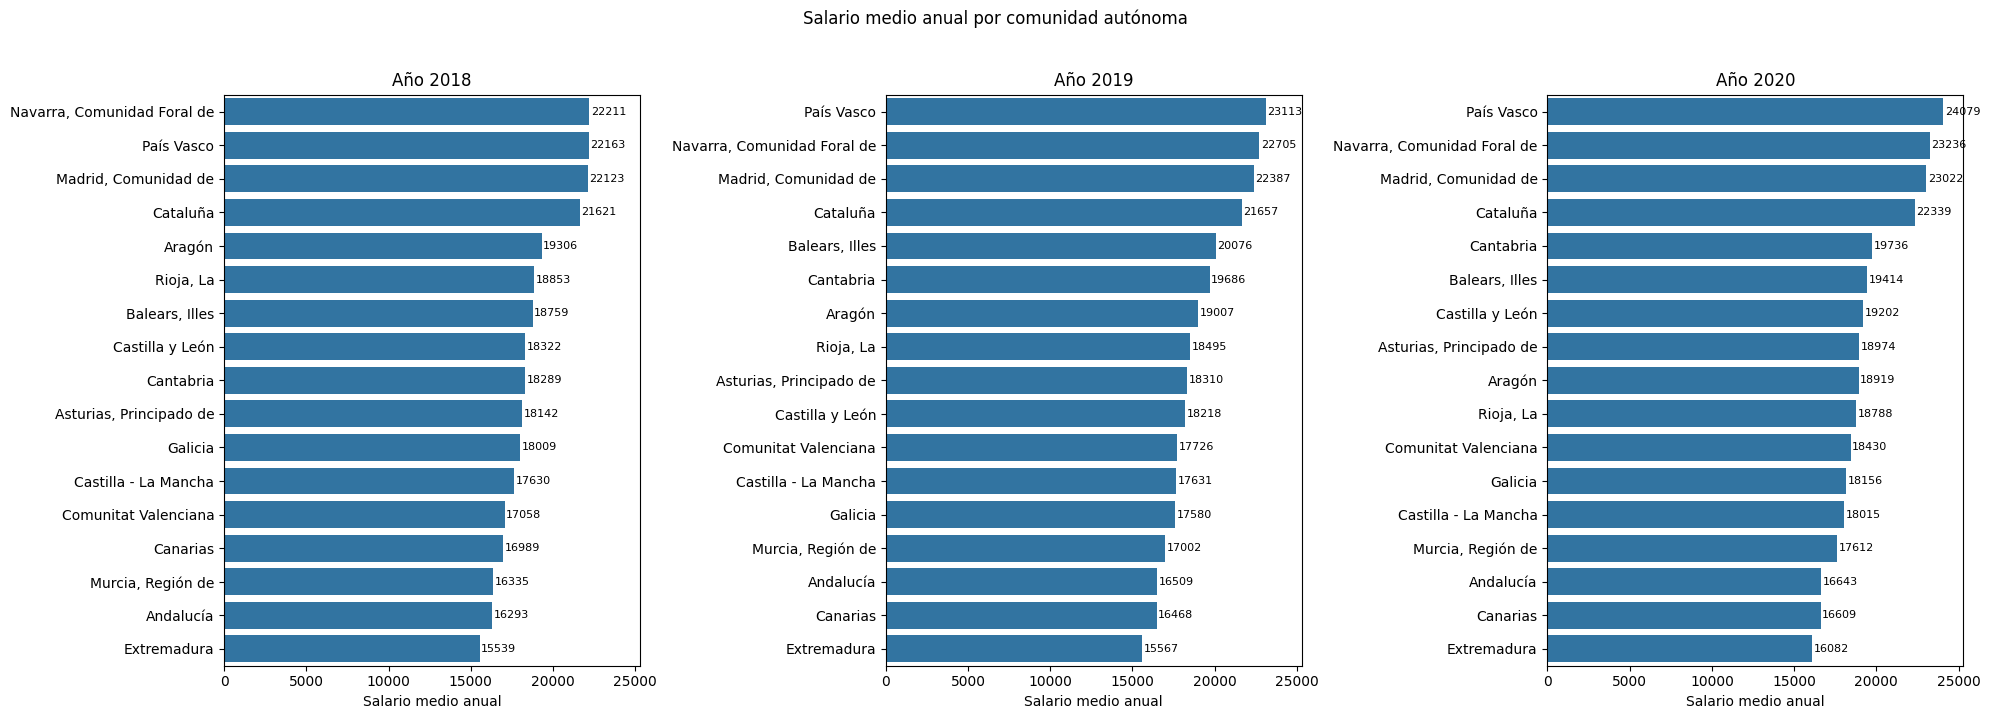

In [10]:
periodos = sorted(df2_nogenero["Periodo"].unique())

fig, axes = plt.subplots(1, len(periodos), figsize=(20, 7), sharex=True)

if len(periodos) == 1:
    axes = [axes]

for ax, periodo in zip(axes, periodos):
    datos = df2_nogenero[df2_nogenero["Periodo"] == periodo].copy()
    datos = datos.sort_values("Total", ascending=False)

    sns.barplot(
        data=datos,
        x="Total",
        y="Comunidades y Ciudades Autónomas",
        ax=ax,
        order=datos["Comunidades y Ciudades Autónomas"]
    )

    ax.set_title(f"Año {periodo}")
    ax.set_xlabel("Salario medio anual")
    ax.set_ylabel("")

    for i, valor in enumerate(datos["Total"]):
        ax.text(valor + 100, i, f"{valor:.0f}", va="center", fontsize=8)

plt.suptitle("Salario medio anual por comunidad autónoma", y=1.02)
plt.tight_layout()
plt.show()

Lo que vemos son los rankings de comunidades autónomas según el salario medio anual, ordenados de mayor a menor, para los años 2018, 2019 y 2020. A simple vista se aprecia que las posiciones más altas están bastante concentradas y presentan cierta estabilidad a lo largo del periodo.

En la parte alta del ranking, el País Vasco se mantiene como la comunidad con mayor salario medio en los dos últimos años, seguido muy de cerca por Navarra, que domina en 2018, y la Comunidad de Madrid, que también se repiten constantemente en la tercera posición. Cataluña aparece igualmente en la zona alta, aunque sin llegar a liderar en ningún año.

Si observamos los valores, el máximo y el mínimo aumentan ligeramente con el paso del tiempo, lo que indica una tendencia al alza en los salarios medios de las posiciones más altas y bajas. Por el centro se mantienen más estable, lo que sugiere que el incremento salarial no es completamente uniforme.

En la zona media del ranking encontramos comunidades como Aragón; La Rioja, que van descendiendo pero siguen en mitad de tabla. Cantabria, que se mantienen relativamente estable en mitad de tabla, con un pequeño incremento que le hace subir posiciones. Baleares consigue un buen aumento entre  2018 y 2019, pero lo pierde al año siguiente, manteniendose en mitad del ranking.

En la cola tenemos a Extremadura todos los años, seguida de Canarias; Murcia; Andalucía. La Comunidad Valenciana; Galicia; Castilla La Mancha, se situan también por la parte media-baja de la tabla durante todo el periódo.

Análisis Multivariante.

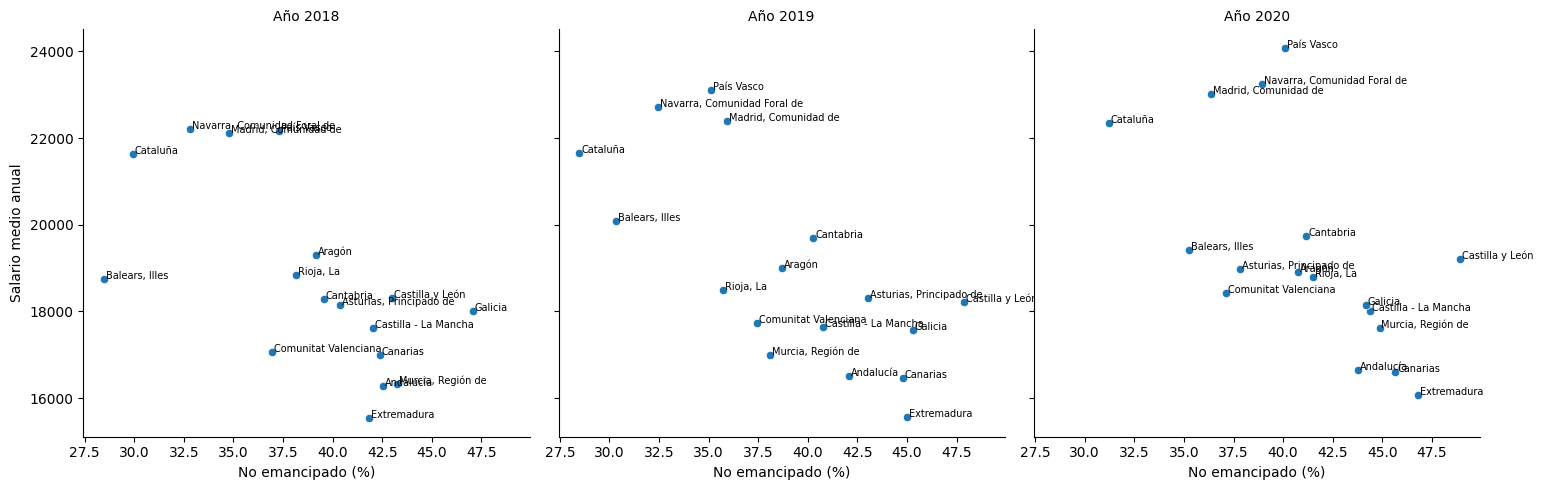

In [11]:
df_scatter = df1_nogenero.merge(
    df2_nogenero,
    left_on=["Comunidades y Ciudades Autónomas", "periodo"],
    right_on=["Comunidades y Ciudades Autónomas", "Periodo"],
    how="inner"
)

g = sns.relplot(
    data=df_scatter,
    x="No emancipado%",
    y="Total",
    col="periodo",
    kind="scatter",
    height=5,
    aspect=1
)

for ax, periodo in zip(g.axes.flat, sorted(df_scatter["periodo"].unique())):
    datos = df_scatter[df_scatter["periodo"] == periodo]
    for _, row in datos.iterrows():
        ax.text(
            row["No emancipado%"] + 0.1,
            row["Total"],
            row["Comunidades y Ciudades Autónomas"],
            fontsize=7
        )

g.set_axis_labels("No emancipado (%)", "Salario medio anual")
g.set_titles("Año {col_name}")
plt.show()

Aquí podemos ver un gráfico de correspondencia entre el sueldo medio anual y la proporción de personas no emancipadas para cada cada CCAA. Ya los gráficos no están sugiriendo que puede haber una relación entre las dos variables, de manera que, a medida que aumenta el sueldo anual medio, disminuye la proporción de personas no emancipadas. Si nos fijamos, aquellas comunidades que se sitúan más alto, también están más desplazadas a la izquierda indicando una menor proporción de gente no emancipada. Por eso es interesante ver si existe correlación estadísticamente significativa.

In [12]:
tabla_cruzada = df1_nogenero.merge(
    df2_nogenero,
    left_on=["Comunidades y Ciudades Autónomas", "periodo"],
    right_on=["Comunidades y Ciudades Autónomas", "Periodo"],
    how="inner"
)[[
    "Comunidades y Ciudades Autónomas",
    "periodo",
    "No emancipado%",
    "Total"
]]

tabla_cruzada = tabla_cruzada.rename(columns={"Total": "Salario medio anual"})

tabla_no_emancipado = tabla_cruzada.pivot(
    index="Comunidades y Ciudades Autónomas",
    columns="periodo",
    values="No emancipado%"
)

tabla_no_emancipado.columns = [f"no_emancipado_{col}" for col in tabla_no_emancipado.columns]

tabla_salario = tabla_cruzada.pivot(
    index="Comunidades y Ciudades Autónomas",
    columns="periodo",
    values="Salario medio anual"
)

tabla_salario.columns = [f"salario_{col}" for col in tabla_salario.columns]

tabla_final = tabla_no_emancipado.merge(
    tabla_salario,
    left_index=True,
    right_index=True
).reset_index()

tabla_final

,Comunidades y Ciudades Autónomas,no_emancipado_2018,no_emancipado_2019,no_emancipado_2020,salario_2018,salario_2019,salario_2020
0,Andalucía,42.531,42.066,43.754,16293.48,16509.01,16643.35
1,Aragón,39.175,38.679,40.77,19306.31,19006.76,18919.42
2,"Asturias, Principado de",40.356,43.045,37.826,18141.88,18309.70,18973.91
3,"Balears, Illes",28.455,30.324,35.243,18759.36,20075.72,19413.73
4,Canarias,42.376,44.782,45.648,16988.89,16467.90,16608.61
5,Cantabria,39.555,40.283,41.166,18289.24,19686.42,19736.18
6,Castilla - La Mancha,42.031,40.778,44.377,17629.80,17631.22,18014.77
7,Castilla y León,42.978,47.879,48.9,18322.20,18217.73,19201.93
8,Cataluña,29.937,28.484,31.207,21621.47,21656.58,22338.55
9,Comunitat Valenciana,36.95,37.422,37.137,17057.95,17726.16,18430.18


En ésta tabla podemos ver de forma numérica los valores que hemos comentado antes en los gráficos de correspondencia.

In [13]:
for periodo in sorted(tabla_cruzada["periodo"].unique()):
    datos = tabla_cruzada[tabla_cruzada["periodo"] == periodo]

    stat_no, p_no = shapiro(datos["No emancipado%"])
    stat_sal, p_sal = shapiro(datos["Salario medio anual"])

    print(f"Año {periodo}")
    print(f"No emancipado% -> estadístico={stat_no:.4f}, p-valor={p_no:.4f}")
    print(f"Salario medio anual -> estadístico={stat_sal:.4f}, p-valor={p_sal:.4f}")

Año 2018
No emancipado% -> estadístico=0.9424, p-valor=0.3471
Salario medio anual -> estadístico=0.8982, p-valor=0.0634
Año 2019
No emancipado% -> estadístico=0.9749, p-valor=0.8966
Salario medio anual -> estadístico=0.9247, p-valor=0.1776
Año 2020
No emancipado% -> estadístico=0.9820, p-valor=0.9732
Salario medio anual -> estadístico=0.9003, p-valor=0.0687


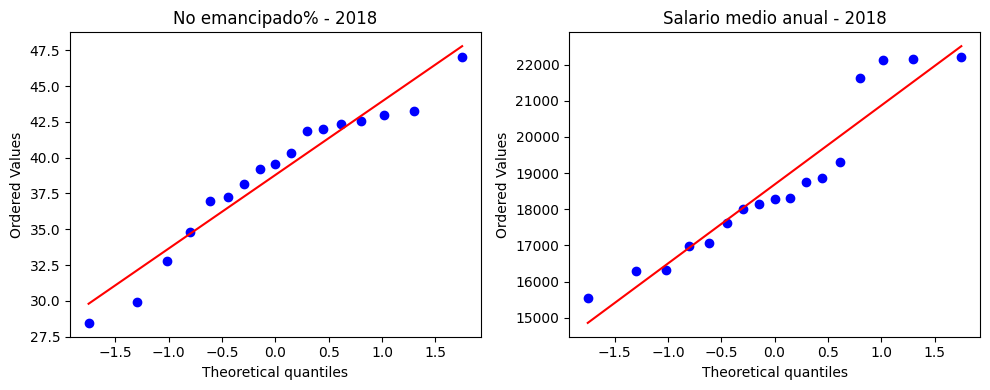

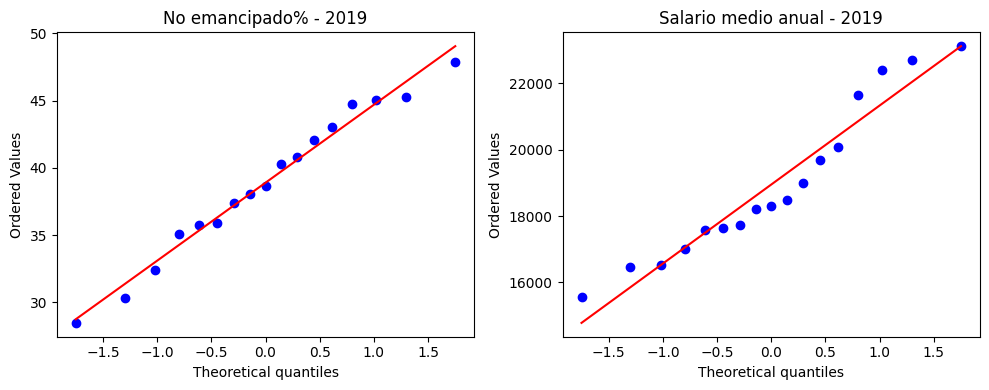

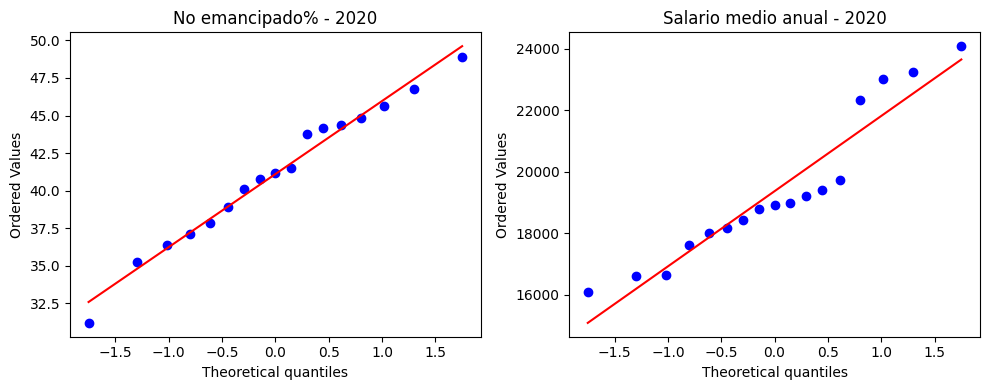

In [14]:
for periodo in sorted(tabla_cruzada["periodo"].unique()):
    datos = tabla_cruzada[tabla_cruzada["periodo"] == periodo]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    stats.probplot(datos["No emancipado%"], dist="norm", plot=axes[0])
    axes[0].set_title(f"No emancipado% - {periodo}")

    stats.probplot(datos["Salario medio anual"], dist="norm", plot=axes[1])
    axes[1].set_title(f"Salario medio anual - {periodo}")

    plt.tight_layout()
    plt.show()

Como habíamos comentado anteriormente, sería interesante medir la relación entre el salario medio y la proporción de personas no emancipadas. Para ello tenemos que realizar primero las pruebas de normalidad, para verificar cuál es el análisis adecuado en este caso.

Como podemos ver el p-valor en todos los años es mayor de 0.05, por eso no podemos rechazar que la variables sigan una distribución normal. Además viendo los Q-Qplot observamos que los valores no están muy dispersos, si no que siguen la línea. De esta manera es suficiente con realizar la prueba de correlación de Pearsons.

In [15]:
for periodo in sorted(tabla_cruzada["periodo"].unique()):
    datos = tabla_cruzada[tabla_cruzada["periodo"] == periodo]

    r, p = pearsonr(
        datos["No emancipado%"],
        datos["Salario medio anual"]
    )

    print(f"Año {periodo}")
    print(f"r = {r:.4f}")
    print(f"p-valor = {p:.4f}")

Año 2018
r = -0.6428
p-valor = 0.0054
Año 2019
r = -0.7130
p-valor = 0.0013
Año 2020
r = -0.6131
p-valor = 0.0089


Tras realizar las pruebas de correlación de Pearsons, obtenemos unos p-valores menores de 0.05 todos los años, lo que nos quiere decir que la correlación entre el sueldo medio anual y la proporción de personas no emancipadas, por CCAA, es estadísticamente significativa. También obtenemos unos valores de r negativos, comprendidos entre -0,61 y -0,71, lo que nos indica que existe una correlación negativa medianamente fuerte entre las variables, que quiere decir que si por ejemplo baja el sueldo medio anual, aumentará la proporción de personas no emancipadas.

In [16]:
for periodo in sorted(tabla_cruzada["periodo"].unique()):
    datos = tabla_cruzada[tabla_cruzada["periodo"] == periodo].copy()

    X = datos["Salario medio anual"]
    y = datos["No emancipado%"]
    
    X = sm.add_constant(X)
    
    modelo = sm.OLS(y, X).fit()

    print(f"\nAño {periodo}")
    print(modelo.summary())


Año 2018
                            OLS Regression Results                            
Dep. Variable:         No emancipado%   R-squared:                       0.413
Model:                            OLS   Adj. R-squared:                  0.374
Method:                 Least Squares   F-statistic:                     10.56
Date:                Mon, 13 Apr 2026   Prob (F-statistic):            0.00538
Time:                        10:43:59   Log-Likelihood:                -46.408
No. Observations:                  17   AIC:                             96.82
Df Residuals:                      15   BIC:                             98.48
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  6

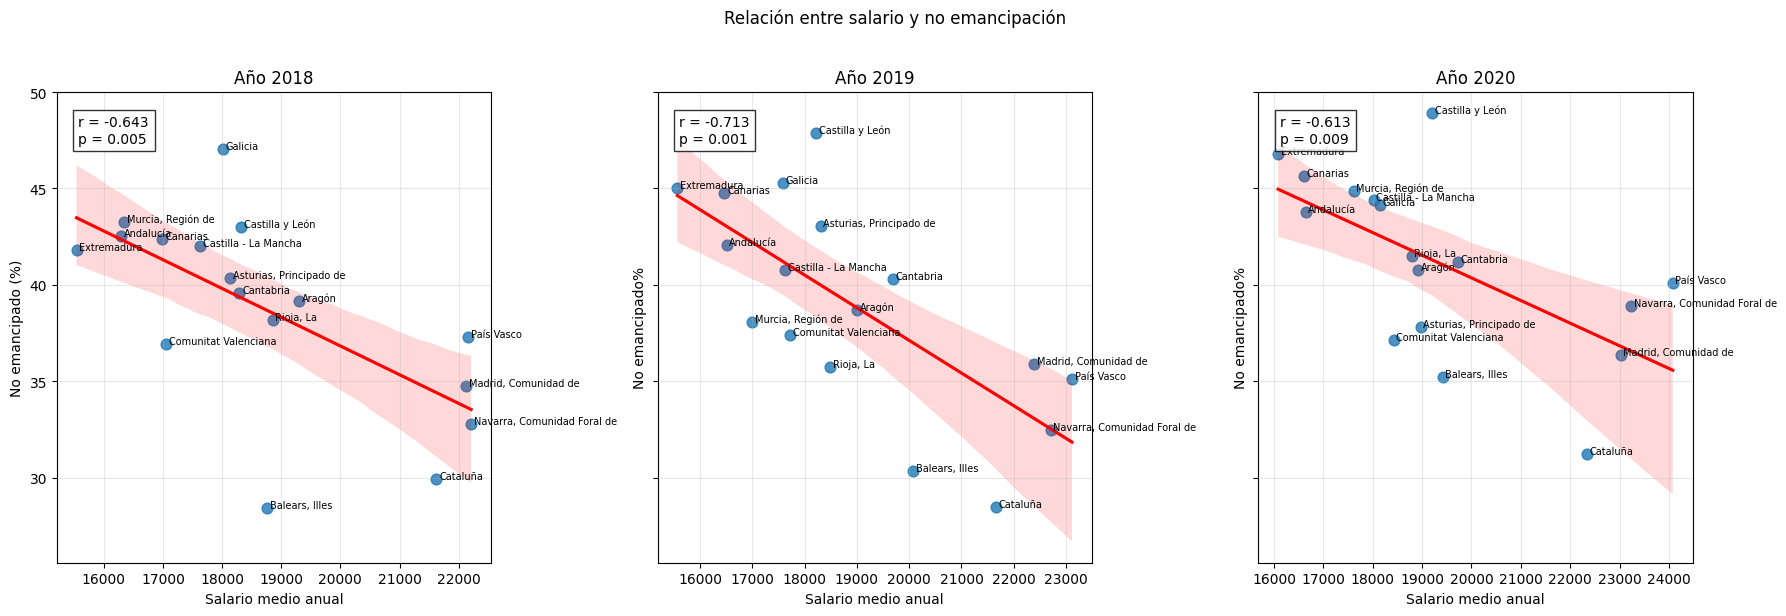

In [17]:
periodos = sorted(tabla_cruzada["periodo"].unique())

fig, axes = plt.subplots(1, len(periodos), figsize=(18, 6), sharey=True)

if len(periodos) == 1:
    axes = [axes]

for ax, periodo in zip(axes, periodos):
    datos = tabla_cruzada[tabla_cruzada["periodo"] == periodo].copy()

    r, p = pearsonr(datos["Salario medio anual"], datos["No emancipado%"])

    sns.regplot(
        data=datos,
        x="Salario medio anual",
        y="No emancipado%",
        ax=ax,
        scatter_kws={"s": 60},
        line_kws={"color": "red"}
    )

    for _, row in datos.iterrows():
        ax.text(
            row["Salario medio anual"] + 50,
            row["No emancipado%"],
            row["Comunidades y Ciudades Autónomas"],
            fontsize=7
        )

    ax.text(
        0.05, 0.95,
        f"r = {r:.3f}\np = {p:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        bbox=dict(facecolor="white", alpha=0.8)
    )

    ax.set_title(f"Año {periodo}")
    ax.set_xlabel("Salario medio anual")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("No emancipado (%)")
plt.suptitle("Relación entre salario y no emancipación", y=1.02)
plt.tight_layout()
plt.show()

Aquí ya hacemos el modelo de regresión que nos permitirá entender mejor como están relacionados los datos. En primer lugar tenemos unas r cuadrado que no varían demasiado entre 2018 y 2020, por lo que podemos decir que es estable, por ejemplo en 2020, el año que puntua más bajo, el modelo explica los cambios en la proporción de no emancipados un 37,6%. También el p-valor de la prueba F-statistic es siempre menor de 0.05, lo que confirma la validez del modelo.

Ahora si vamos a lo interesante y nos fijamos en nuestros coeficientes. Vemos que tenemos valores entre -0.0012 y -0.0017, de nuevo no observamos demasiada variación, confirmando que el modelo es constante, e indicándonos como se comporta la proporción de personas no emancipadas ante una subida de salario. Es decir, si cogemos por ejemplo el coeficiente de 2020, -0.0012, podríamos decir que a medida que aumenta 1€ el salario medio anual, disminuyé 0.0012, el porcentaje de no emancipados. O dicho de otra manera, 1000€ más de salario medio anual son 1.2% menos de personas viviendo en casa de sus padres.

En resumen, aunque el salario medio anual es un factor explicativo en cuanto a la emancipación, tiene una capacidad limitada. Esto nos sugiere pues que existen más factores que influyen en ésta variable, como puede ser el precio de la vivienda o las dinámicas familiares.

Continuación. Análisis Multivariante teniendo en cuenta el género.

In [18]:
tabla_cruzada_sexo = df1.merge(
    df2,
    left_on=["Comunidades y Ciudades Autónomas", "Sexo", "periodo"],
    right_on=["Comunidades y Ciudades Autónomas", "Sexo", "Periodo"],
    how="inner"
)[[
    "Comunidades y Ciudades Autónomas",
    "Sexo",
    "periodo",
    "No emancipado%",
    "Total"
]]

tabla_cruzada_sexo = tabla_cruzada_sexo.rename(columns={
    "Total": "Sueldo medio anual"
})

tabla_cruzada_sexo = tabla_cruzada_sexo.sort_values(
    ["periodo", "Comunidades y Ciudades Autónomas", "Sexo"]
)

tabla_final_sexo = tabla_cruzada_sexo.pivot(
    index="Comunidades y Ciudades Autónomas",
    columns=["periodo", "Sexo"],
    values=["No emancipado%", "Sueldo medio anual"]
)

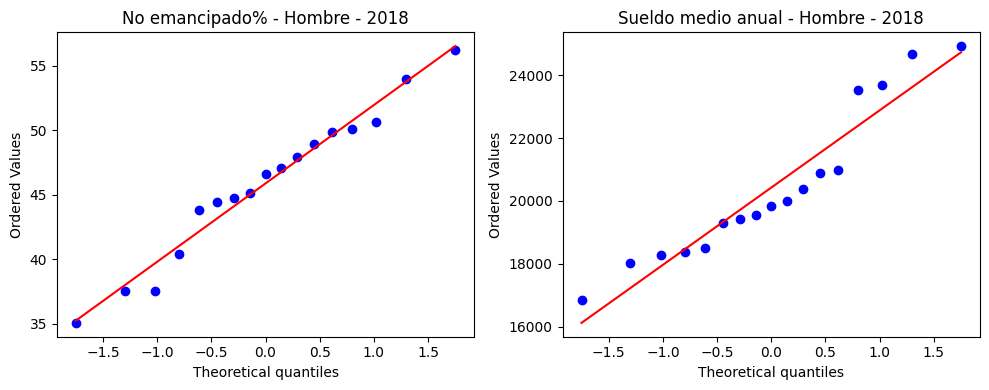

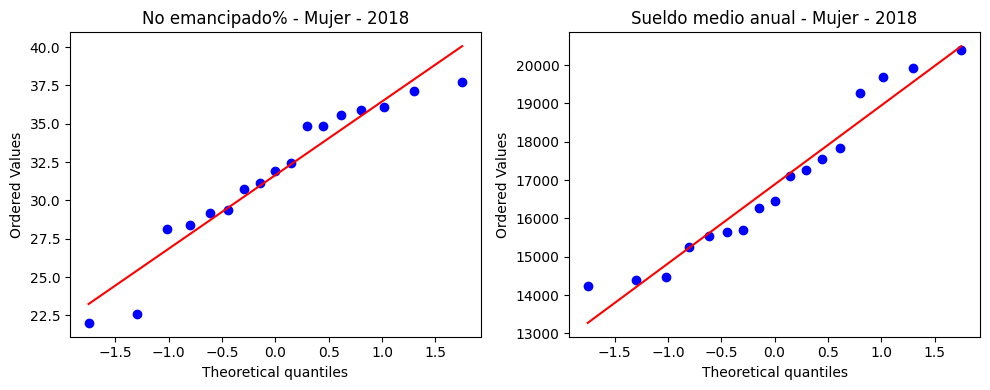

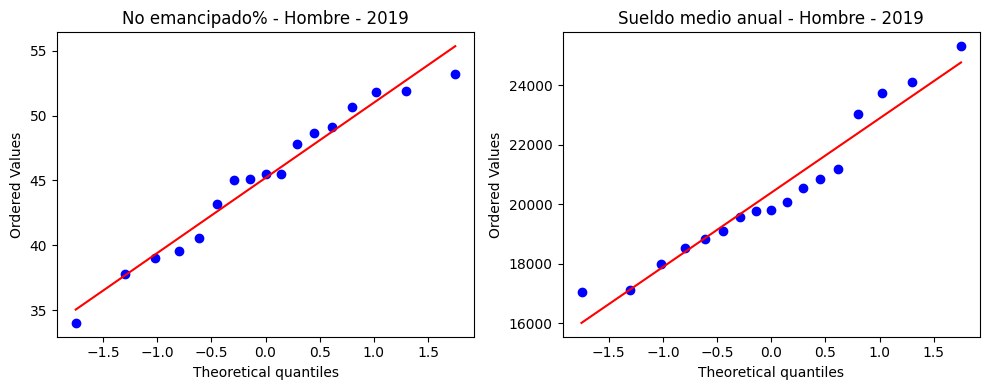

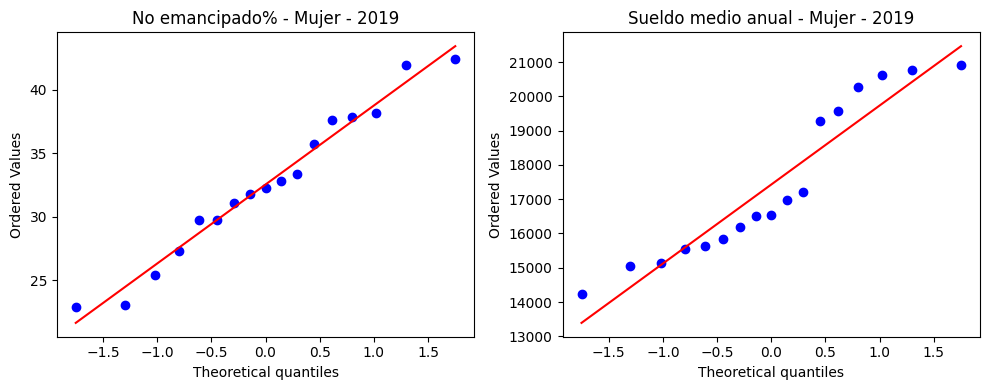

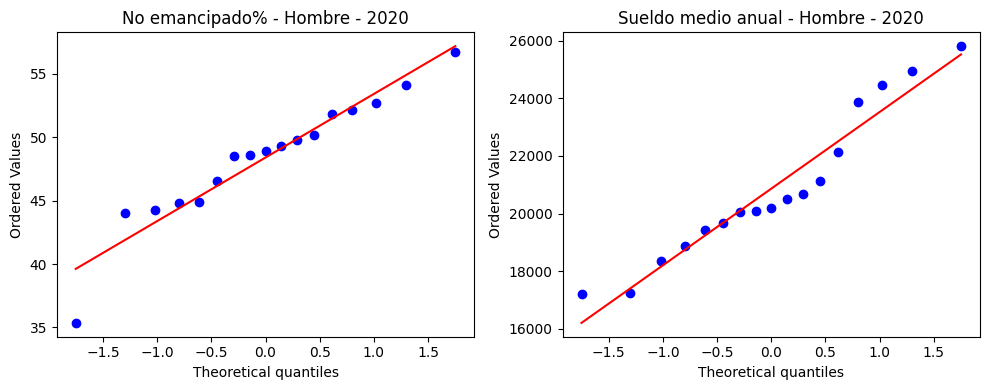

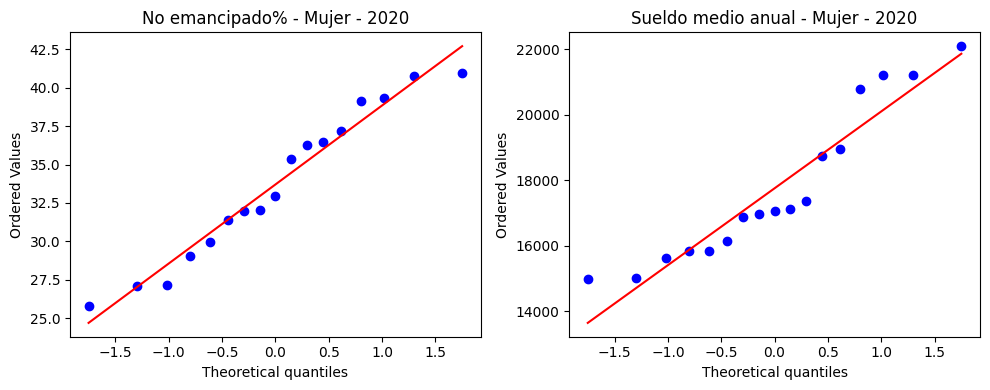

In [19]:
for periodo in sorted(tabla_cruzada_sexo["periodo"].unique()):
    for sexo in sorted(tabla_cruzada_sexo["Sexo"].unique()):
        datos = tabla_cruzada_sexo[
            (tabla_cruzada_sexo["periodo"] == periodo) &
            (tabla_cruzada_sexo["Sexo"] == sexo)
        ]

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        stats.probplot(datos["No emancipado%"], dist="norm", plot=axes[0])
        axes[0].set_title(f"No emancipado% - {sexo} - {periodo}")

        stats.probplot(datos["Sueldo medio anual"], dist="norm", plot=axes[1])
        axes[1].set_title(f"Sueldo medio anual - {sexo} - {periodo}")

        plt.tight_layout()
        plt.show()

In [20]:
for periodo in sorted(tabla_cruzada_sexo["periodo"].unique()):
    for sexo in sorted(tabla_cruzada_sexo["Sexo"].unique()):
        datos = tabla_cruzada_sexo[
            (tabla_cruzada_sexo["periodo"] == periodo) &
            (tabla_cruzada_sexo["Sexo"] == sexo)
        ]

        stat_no, p_no = shapiro(datos["No emancipado%"])
        stat_sal, p_sal = shapiro(datos["Sueldo medio anual"])

        print(f"Año {periodo} - {sexo}")
        print(f"No emancipado% -> estadístico={stat_no:.4f}, p-valor={p_no:.4f}")
        print(f"Sueldo medio anual -> estadístico={stat_sal:.4f}, p-valor={p_sal:.4f}")

Año 2018 - Hombre
No emancipado% -> estadístico=0.9709, p-valor=0.8332
Sueldo medio anual -> estadístico=0.9085, p-valor=0.0942
Año 2018 - Mujer
No emancipado% -> estadístico=0.9231, p-valor=0.1667
Sueldo medio anual -> estadístico=0.9300, p-valor=0.2173
Año 2019 - Hombre
No emancipado% -> estadístico=0.9586, p-valor=0.6059
Sueldo medio anual -> estadístico=0.9378, p-valor=0.2930
Año 2019 - Mujer
No emancipado% -> estadístico=0.9645, p-valor=0.7167
Sueldo medio anual -> estadístico=0.8855, p-valor=0.0391
Año 2020 - Hombre
No emancipado% -> estadístico=0.9410, p-valor=0.3302
Sueldo medio anual -> estadístico=0.9295, p-valor=0.2139
Año 2020 - Mujer
No emancipado% -> estadístico=0.9471, p-valor=0.4116
Sueldo medio anual -> estadístico=0.8901, p-valor=0.0465


Como en el análisis anterior realizamos pruebas para comprobar la normalidad. Obtenemos que siguen una distribución normal en la mayoría de los años y podriamos pasar a realizar Pearsons. Pero también vamos a realizar Spearman para comprobar la robustez, porque como decimos el p-valor en 2019 y 2020 para las mujeres es menor de 0.05.

In [21]:
for periodo in sorted(tabla_cruzada_sexo["periodo"].unique()):
    for sexo in sorted(tabla_cruzada_sexo["Sexo"].unique()):
        datos = tabla_cruzada_sexo[
            (tabla_cruzada_sexo["periodo"] == periodo) &
            (tabla_cruzada_sexo["Sexo"] == sexo)
        ]

        r, p = pearsonr(
            datos["No emancipado%"],
            datos["Sueldo medio anual"]
        )

        print(f"Año {periodo} - {sexo}")
        print(f"r = {r:.4f}")
        print(f"p-valor = {p:.4f}")

Año 2018 - Hombre
r = -0.5903
p-valor = 0.0126
Año 2018 - Mujer
r = -0.6526
p-valor = 0.0045
Año 2019 - Hombre
r = -0.6170
p-valor = 0.0083
Año 2019 - Mujer
r = -0.7607
p-valor = 0.0004
Año 2020 - Hombre
r = -0.5226
p-valor = 0.0314
Año 2020 - Mujer
r = -0.5526
p-valor = 0.0214


In [22]:
for periodo in sorted(tabla_cruzada_sexo["periodo"].unique()):
    for sexo in sorted(tabla_cruzada_sexo["Sexo"].unique()):
        datos = tabla_cruzada_sexo[
            (tabla_cruzada_sexo["periodo"] == periodo) &
            (tabla_cruzada_sexo["Sexo"] == sexo)
        ]

        r_pearson, p_pearson = pearsonr(
            datos["No emancipado%"],
            datos["Sueldo medio anual"]
        )

        r_spearman, p_spearman = spearmanr(
            datos["No emancipado%"],
            datos["Sueldo medio anual"]
        )

        print(f"A?o {periodo} - {sexo}")
        print(f"Pearson r = {r_pearson:.4f}")
        print(f"Pearson p-valor = {p_pearson:.4f}")
        print(f"Spearman rho = {r_spearman:.4f}")
        print(f"Spearman p-valor = {p_spearman:.4f}")

A?o 2018 - Hombre
Pearson r = -0.5903
Pearson p-valor = 0.0126
Spearman rho = -0.5784
Spearman p-valor = 0.0150
A?o 2018 - Mujer
Pearson r = -0.6526
Pearson p-valor = 0.0045
Spearman rho = -0.6593
Spearman p-valor = 0.0040
A?o 2019 - Hombre
Pearson r = -0.6170
Pearson p-valor = 0.0083
Spearman rho = -0.5980
Spearman p-valor = 0.0112
A?o 2019 - Mujer
Pearson r = -0.7607
Pearson p-valor = 0.0004
Spearman rho = -0.7574
Spearman p-valor = 0.0004
A?o 2020 - Hombre
Pearson r = -0.5226
Pearson p-valor = 0.0314
Spearman rho = -0.5098
Spearman p-valor = 0.0366
A?o 2020 - Mujer
Pearson r = -0.5526
Pearson p-valor = 0.0214
Spearman rho = -0.5221
Spearman p-valor = 0.0316


De nuevo obtenemos unos valores que nos indican una correlación negativa estadísticamente significativa. Si comparamos la r de hombre y mujer en cada año, la de las mujeres supera a la de los hombres, esto nos puede dejar ver que el salario medio puede llegar a influir más para las mujeres.

In [23]:
for periodo in sorted(tabla_cruzada_sexo["periodo"].unique()):
    for sexo in sorted(tabla_cruzada_sexo["Sexo"].unique()):
        datos = tabla_cruzada_sexo[
            (tabla_cruzada_sexo["periodo"] == periodo) &
            (tabla_cruzada_sexo["Sexo"] == sexo)
        ].copy()

        X = datos["Sueldo medio anual"]
        y = datos["No emancipado%"]

        X = sm.add_constant(X)

        modelo = sm.OLS(y, X).fit()

        print(f"\nAño {periodo} - {sexo}")
        print(modelo.summary())


Año 2018 - Hombre
                            OLS Regression Results                            
Dep. Variable:         No emancipado%   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.305
Method:                 Least Squares   F-statistic:                     8.020
Date:                Mon, 13 Apr 2026   Prob (F-statistic):             0.0126
Time:                        10:44:01   Log-Likelihood:                -49.864
No. Observations:                  17   AIC:                             103.7
Df Residuals:                      15   BIC:                             105.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const            

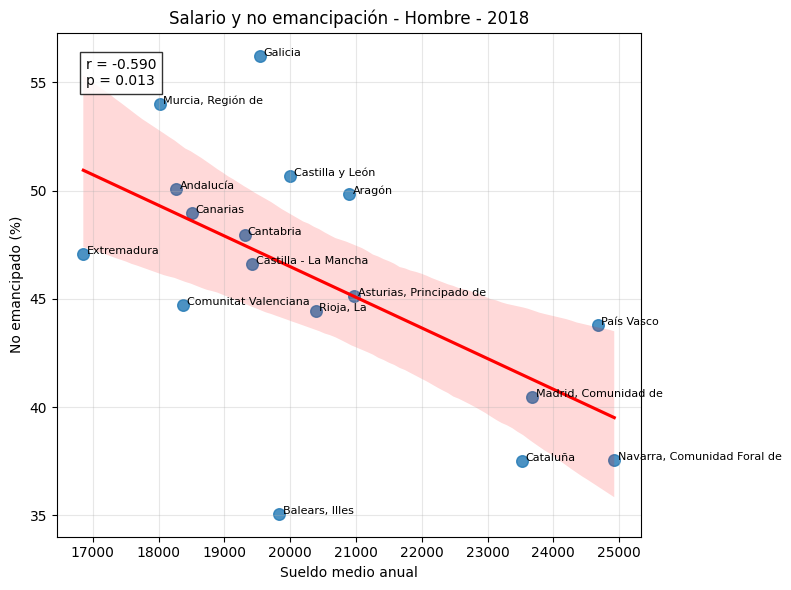

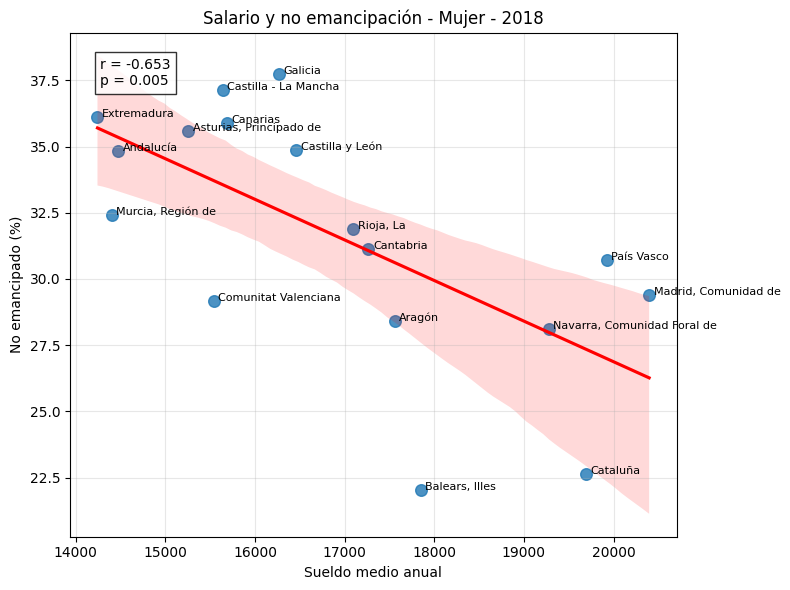

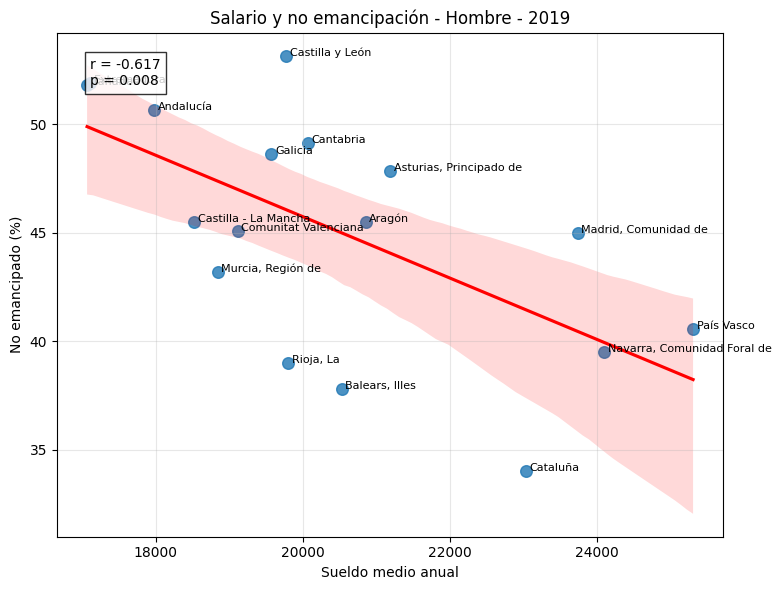

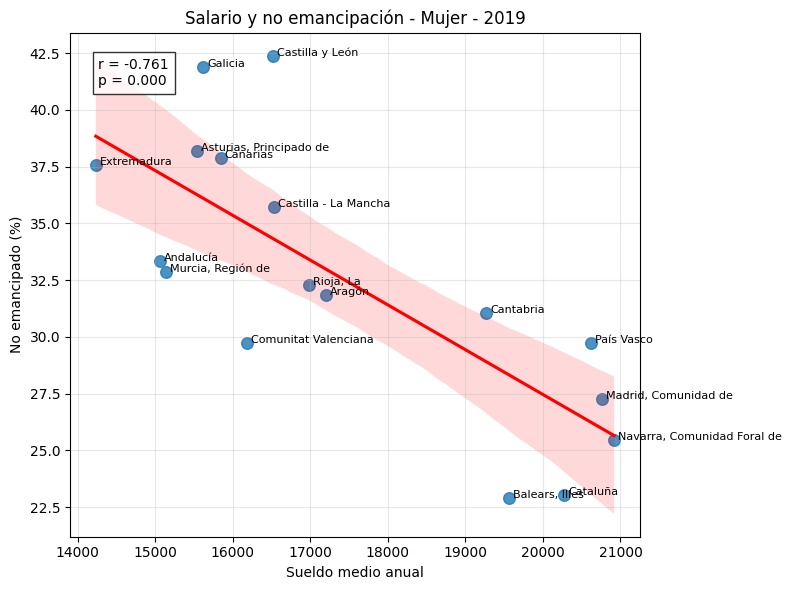

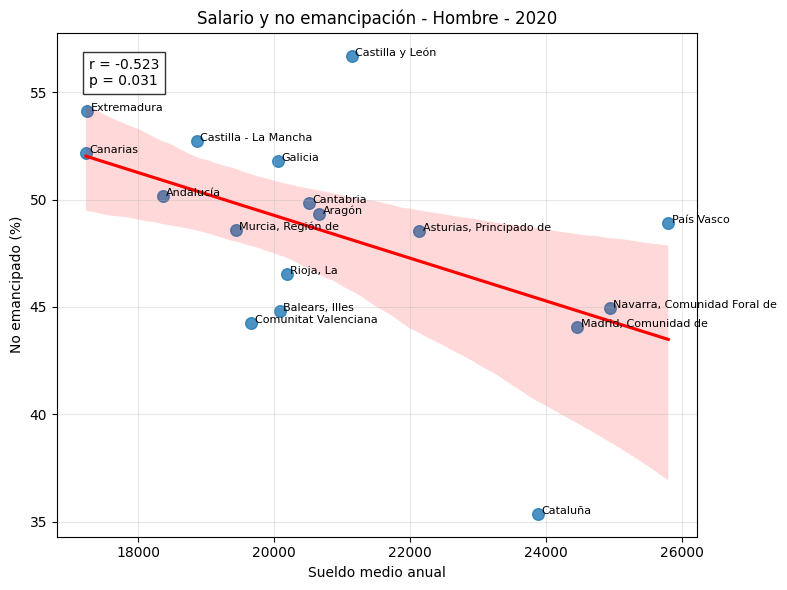

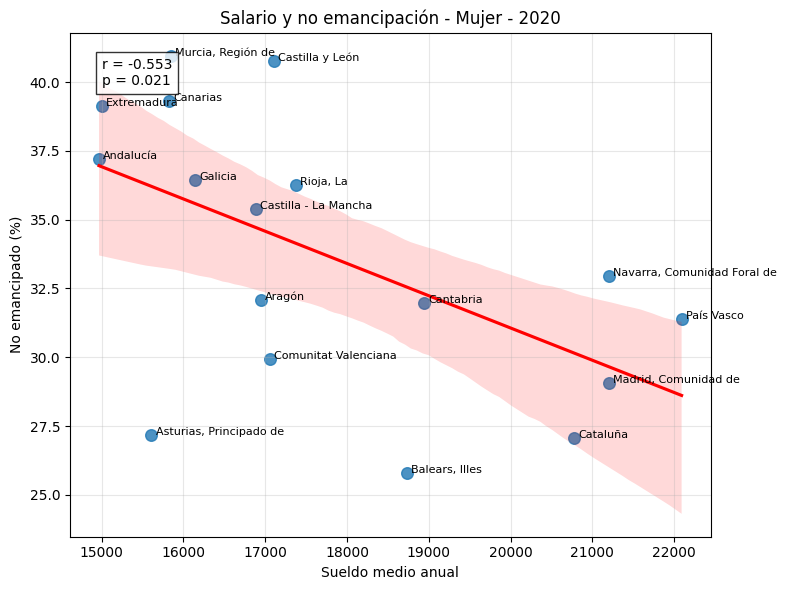

In [24]:
for periodo in sorted(tabla_cruzada_sexo["periodo"].unique()):
    for sexo in sorted(tabla_cruzada_sexo["Sexo"].unique()):
        datos = tabla_cruzada_sexo[
            (tabla_cruzada_sexo["periodo"] == periodo) &
            (tabla_cruzada_sexo["Sexo"] == sexo)
        ].copy()

        r, p = pearsonr(datos["Sueldo medio anual"], datos["No emancipado%"])

        plt.figure(figsize=(8, 6))
        sns.regplot(
            data=datos,
            x="Sueldo medio anual",
            y="No emancipado%",
            scatter_kws={"s": 70},
            line_kws={"color": "red"}
        )

        for _, row in datos.iterrows():
            plt.text(
                row["Sueldo medio anual"] + 50,
                row["No emancipado%"],
                row["Comunidades y Ciudades Autónomas"],
                fontsize=8
            )

        plt.text(
            0.05, 0.95,
            f"r = {r:.3f}\np = {p:.3f}",
            transform=plt.gca().transAxes,
            ha="left",
            va="top",
            bbox=dict(facecolor="white", alpha=0.8)
        )

        plt.title(f"Salario y no emancipación - {sexo} - {periodo}")
        plt.xlabel("Sueldo medio anual")
        plt.ylabel("No emancipado (%)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

Aquí aplicamos el modelo de regresión separando por sexo, lo que nos permite ver si el efecto del salario sobre la emancipación cambia entre hombres y mujeres.

En primer lugar, si nos fijamos en los r cuadrado, observamos que en el caso de los hombres son más bajos (por ejemplo, en 2018 es 0.348), mientras que en las mujeres son algo más altos, todos los años (0.426 en 2018). Esto nos indica que el modelo explica mejor la variación de la no emancipación en mujeres que en hombres. Es decir, el salario parece tener mayor capacidad explicativa en el caso femenino.

Además, los p-valores del F-statistic son siempre menores a 0.05 en ambos casos, lo que confirma que los modelos son estadísticamente significativos tanto para hombres como para mujeres. Por tanto, la relación entre salario y emancipación existe en los dos grupos.

Si vamos a los coeficientes, vemos que en ambos casos son negativos y bastante similares, lo que confirma una relación inversa: a mayor salario, menor proporción de no emancipados. En hombres, el coeficiente en 2020 es aproximadamente -0.0010, mientras que en mujeres es ligeramente más intenso, en torno a -0.0012.

Esto implica que el efecto del salario es un poco más fuerte en mujeres. Por ejemplo, un aumento de 1000€ en el salario medio anual supondría aproximadamente un 1% menos de no emancipados en hombres, frente a un 1.5% en mujeres. Aunque la diferencia no es enorme, sí es consistente.

Si lo relacionamos con los gráficos de dispersión, esto también se refleja en los coeficientes de correlación: en mujeres son más negativos (por ejemplo, r ≈ -0.65), mientras que en hombres son algo más moderados (en torno a -0.59 en 2018 y -0.52 en 2020). Esto refuerza la idea de que la relación salario–emancipación es más fuerte en mujeres.

También se observa que en hombres la relación pierde algo de intensidad en 2020 (coeficiente y correlación más débiles), mientras que en mujeres se mantiene más estable, lo que sugiere que el salario sigue siendo un factor más consistente para explicar la emancipación femenina.

En resumen, el salario medio anual es un factor explicativo en ambos casos, pero parece tener un mayor peso en mujeres, que en hombres. Aun así, en los dos grupos su capacidad explicativa es limitada, lo que indica que existen otros factores importantes, como el mercado laboral, el acceso a la vivienda o factores culturales, que influyen en la emancipación más allá del nivel salarial.

In [25]:
datos_modelo = tabla_cruzada_sexo.copy()

# Dummy de genero: 0 = Hombre, 1 = Mujer
datos_modelo["genero_dummy"] = datos_modelo["Sexo"].map({
    "Hombre": 0,
    "Mujer": 1
})

X = datos_modelo[["Sueldo medio anual", "genero_dummy"]]
y = datos_modelo["No emancipado%"]

X = sm.add_constant(X)

modelo_conjunto = sm.OLS(y, X).fit()

print(modelo_conjunto.summary())

                            OLS Regression Results                            
Dep. Variable:         No emancipado%   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     149.8
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.14e-30
Time:                        10:44:02   Log-Likelihood:                -294.59
No. Observations:                 102   AIC:                             595.2
Df Residuals:                      99   BIC:                             603.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 73.5183      3

Aquí ya introducimos un modelo de regresión más completo, donde además del salario medio anual incorporamos el género como variable dummy (0 = hombre, 1 = mujer). Esto nos permite ver no solo el efecto del salario, sino también si existen diferencias estructurales entre hombres y mujeres en la emancipación.

En primer lugar, si nos fijamos en el r cuadrado, vemos que es bastante alto (0.752), lo que supone un salto importante respecto a los modelos anteriores. Es decir, ahora el modelo explica un 75.2% de la variación en la proporción de no emancipados, lo que indica una mejora clara en la capacidad explicativa al introducir el género.

Además, el p-valor del F-statistic es prácticamente 0 (1.14e-30), lo que confirma que el modelo es altamente significativo en su conjunto.

Si vamos a los coeficientes, empezamos por el salario medio anual, que sigue siendo negativo (-0.0013) y significativo. Esto confirma lo que ya habíamos visto: a mayor salario, menor proporción de no emancipados. En términos prácticos, un aumento de 1000€ en el salario medio implica aproximadamente un 1.3% menos de personas viviendo con sus padres, manteniéndose muy en línea con los modelos anteriores.

Ahora bien, lo más interesante aquí es el coeficiente de la variable de género (-18.0805). Al estar codificada como 0 = hombre y 1 = mujer, este valor nos indica que, manteniendo constante el salario, las mujeres tienen en promedio 18 puntos porcentuales menos de no emancipación que los hombres. Es decir, las mujeres se emancipan significativamente más que los hombres.

Además, este coeficiente es altamente significativo (p-valor = 0.000), lo que refuerza la robustez de esta diferencia.

Si conectamos esto con los análisis anteriores, vemos que no solo el salario influye en la emancipación, sino que el género introduce una diferencia estructural muy fuerte. De hecho, el impacto del género es mucho mayor que el del salario en términos absolutos, lo que sugiere que las dinámicas de emancipación no son iguales para hombres y mujeres.

En resumen, el salario sigue siendo un factor relevante y consistente, pero al introducir el género vemos que la capacidad explicativa del modelo aumenta considerablemente y que existen diferencias muy marcadas entre hombres y mujeres. Esto apunta a que la emancipación no depende únicamente de factores económicos, sino también de factores sociales y de género que condicionan de forma importante el comportamiento de ambos grupos.

In [26]:
datos_modelo["interaccion"] = (
    datos_modelo["Sueldo medio anual"] * datos_modelo["genero_dummy"]
)

X = datos_modelo[["Sueldo medio anual", "genero_dummy", "interaccion"]]
X = sm.add_constant(X)

modelo_interaccion = sm.OLS(y, X).fit()
print(modelo_interaccion.summary())

                            OLS Regression Results                            
Dep. Variable:         No emancipado%   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     99.44
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.28e-29
Time:                        10:44:02   Log-Likelihood:                -294.37
No. Observations:                 102   AIC:                             596.7
Df Residuals:                      98   BIC:                             607.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 71.2183      5

Aquí damos un paso más en el modelo e introducimos una interacción entre el salario medio anual y el género. Esto nos permite analizar no solo si hombres y mujeres difieren en nivel de emancipación, sino si el efecto del salario es distinto según el género.

En primer lugar, si nos fijamos en el r cuadrado, vemos que es prácticamente igual al modelo anterior (0.753 frente a 0.752), por lo que la capacidad explicativa se mantiene estable. Es decir, el modelo sigue explicando en torno al 75% de la variación en la no emancipación, pero sin mejorar realmente al introducir la interacción.

Además, el p-valor del F-statistic sigue siendo prácticamente 0 (1.28e-29), lo que confirma que el modelo en su conjunto sigue siendo altamente significativo.

Si vamos a los coeficientes y nos fijamos en el salario medio anual, sigue siendo negativo (-0.0012) y significativo. Esto confirma de nuevo que a mayor salario, menor proporción de no emancipados, con un efecto similar al de modelos anteriores (unos 1.2% menos por cada 1000€ adicionales).

En cuanto a la variable de género, vemos que el coeficiente sigue siendo negativo (-13.38), lo que indica que las mujeres presentan menor proporción de no emancipación que los hombres. Sin embargo, aquí el p-valor es 0.070, algo por encima de 0.05, lo que implica que aquí que hay menos proporción de mujeres en casa de sus padres, pierde significatividad estadística para este modelo. Es decir, la diferencia entre hombres y mujeres ya no es tan fuerte cuando introducimos la interacción.

Ahora bien, lo más importante aquí es el término de interacción, que tiene el coeficiente muy pequeño (-0.0003) y no es significativo, ya que su p valor es de 0.517. Esto nos indica que no hay evidencia de que el efecto del salario sobre la emancipación sea diferente entre hombres y mujeres. Es decir, el salario afecta de forma muy similar a ambos grupos. En otras palabras, aunque hombres y mujeres pueden tener distintos niveles de emancipación, la relación entre salario y emancipación, la pendiente de la que hablabamos antes, es prácticamente la misma para ambos.

En resumen, al introducir la interacción vemos que el modelo no mejora y que el efecto diferencial del salario por género no es significativo. Esto sugiere que el salario influye de forma parecida en hombres y mujeres, y que las diferencias de género observadas anteriormente responden más a diferencias de nivel estructural o social, que a diferencias salariales en realidad.